# Real-space Chern density for amorphous systems

Because `topology.real_space_chern`'s marker needs no periodicity or Bloch Hamiltonian -- only
ground-state projectors on whatever real-space geometry is given -- it applies unchanged to
structurally disordered systems where a clean Brillouin zone doesn't exist, e.g. a lattice with
dilute vacancies. Below, several interior sites are removed from a Haldane-model island (structural
disorder breaking translational symmetry entirely) and the bulk marker, averaged over the
*remaining* innermost sites, still plateaus close to the quantized Chern number -- the topological
marker survives disorder that would make a momentum-space calculation meaningless.

Bulk marker average (vacancy-disordered island): 1.8554077213859026


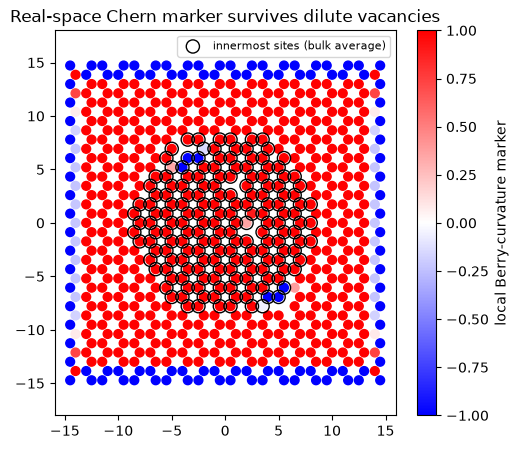

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import islands, topology

g = islands.get_geometry(name="honeycomb",n=10,nedges=4,rot=0.0,clean=False)
np.random.seed(2)
rc = g.r.mean(axis=0)
d = np.linalg.norm(g.r-rc,axis=1)
interior = np.argsort(d)[:len(g.r)//3] # candidates well away from the boundary
vac = np.random.choice(interior,size=4,replace=False)
g2 = g.remove(list(vac)) # dilute vacancies: structural disorder, no periodicity left

h = g2.get_hamiltonian()
h.add_haldane(0.2)
(r,c) = topology.real_space_chern(h)

bulk = np.argsort(np.linalg.norm(r-r.mean(axis=0),axis=1))[:len(r)//4]
print("Bulk marker average (vacancy-disordered island):",np.mean(c[bulk]))

plt.figure(figsize=(5.5,5))
sc = plt.scatter(r[:,0],r[:,1],c=c,cmap="bwr",vmin=-1.0,vmax=1.0,s=40)
plt.scatter(r[bulk,0],r[bulk,1],facecolors="none",edgecolors="k",s=90,
            label="innermost sites (bulk average)")
plt.colorbar(sc,label="local Berry-curvature marker")
plt.legend(loc="upper right",fontsize=8)
plt.axis("equal")
plt.title("Real-space Chern marker survives dilute vacancies")
plt.show()